# Notebook 2: Mathematical Specification and Scalar Forward Propagation
## Neural Network from Scratch: Binary MNIST Classification

## 1. Notebook Overview
In Notebook 1, we prepared the MNIST dataset for binary classification by retaining only images representing the digits (0) and (1). We also reshaped and normalized the images so that they could eventually be passed into a neural network.


Before training a neural network, however, we need to understand exactly how a prediction is computed.


This notebook focuses exclusively on **forward propagation**, which is the process of moving information from the input layer through the hidden layer and finally to the output layer.


We will intentionally begin with scalar calculations and explicit Python loops rather than immediately using NumPy matrix multiplication. Although loops are computationally inefficient, they make every multiplication and addition visible.


The notebook follows this sequence:
1. Define a one-hidden-layer neural-network architecture.
2. specify the dimensions of every input, weight, bias, and activation;
3. derive the forward-propagation equations;
4. implement one neuron using scalar operations;
5. extend the implementation to an entire hidden layer using loops;
6. manually verify the loop implementation on a small synthetic example;
7. confirm the loop implementation using vectorized NumPy calculations;
8. apply the scalar implementation to one MNIST image.
   
At this stage, the network will use randomly initialized parameters. **Therefore, it is not expected to classify MNIST images accurately yet.**


The goal is to understand the computation that produces a prediction.

## 2. Import Required Libraries
We will use:
- NumPy for numerical operations and parameter storage;
- Matplotlib for displaying an MNIST image.

Although NumPy supports efficient matrix multiplication, the primary implementation in this notebook will use explicit loops.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path

## 3. Reproducibility
### Explanation
Neural-network weights are usually initialized randomly.
Without a fixed random seed, the initial weights would change whenever the notebook is rerun. That would cause the network's initial outputs to change as well.

Setting a seed gives us reproducible results:
$$
\text{same random seed}
\Longrightarrow
\text{same initial weights}
\Longrightarrow
\text{same initial predictions}.
$$
Reproducibility will be especially important later when we compare:
- scalar Python loops;
- vectorized NumPy operations;
- a TensorFlow implementation.

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

# Part I: Mathematical Specification
## 4. Define the Binary Classification Problem
Each original MNIST image contains $(28 \times 28)$ grayscale pixels.
After flattening an image, one observation becomes a vector containing
$
28 \times 28 = 784
$
input values.
We write one input image as
$$
\begin{bmatrix}
x_1 \
\\
x_2 \
\\
\vdots \
\\
x_{784}
\end{bmatrix}
\in \mathbb{R}^{784}.
$$
Each normalized pixel value satisfies
$$
0 \leq x_j \leq 1.
$$
The target variable is
$$
y =
\begin{cases}
0, & \text{if the image represents digit 0},\
\\
1, & \text{if the image represents digit 1}.
\end{cases}
$$
The neural network will produce an output
$$
\hat{y} \in (0,1),
$$
which we interpret as
$$
P(y=1 \mid \mathbf{x}).
$$
For example:
- $\hat{y}=0.03$ means the model assigns a low probability to digit (1);
- $\hat{y}=0.92$ means the model assigns a high probability to digit (1).
  
A decision threshold of (0.5) can later convert this probability into a predicted class:
$$
\begin{cases}
0, & \hat{y}<0.5,\
\\
1, & \hat{y}\geq 0.5.
\end{cases}
$$

## 5. Define a One-Hidden-Layer Architecture
We will use the following neural-network architecture:
$$
784 \longrightarrow H \longrightarrow 1.
$$
The three layers are:
1. an input layer containing 784 pixel values;
2. one hidden layer containing (H) neurons;
3. one output neuron for binary classification.

For the initial MNIST implementation, we will choose
$
H=8.
$
Therefore, the architecture is
$$
784 \longrightarrow 8 \longrightarrow 1.
$$

This is intentionally a small network.
The hidden layer is large enough to demonstrate how multiple neurons work together, while remaining small enough for us to inspect individual calculations.

In [3]:
input_size = 784 
hidden_size = 8 
output_size = 1 
print("Input units:", input_size) 
print("Hidden units:", hidden_size) 
print("Output units:", output_size)

Input units: 784
Hidden units: 8
Output units: 1


## 6. Layer Notation
We use superscripts to identify the neural-network layer.
- Layer (0): input layer
- Layer (1): hidden layer
- Layer (2): output layer

The input vector is also treated as the activation of layer (0):
$$
\mathbf{a}^{(0)}=\mathbf{x}.
$$

For the hidden layer, we first calculate the linear component:

$$
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}.
$$
We then apply an activation function:

$$
\sigma\left(\mathbf{z}^{(1)}\right).
$$
For the output layer:

$$
\mathbf{W}^{(2)}\mathbf{a}^{(1)}
+
b^{(2)}.
$$
Finally,

$$
\sigma\left(z^{(2)}\right).
$$
Because there is only one output neuron, we identify the final activation with the prediction:
$$
\hat{y}=a^{(2)}.
$$

## 7. Difference Between (z) and (a)
For every neuron, two values are important.
### Pre-activation value
The pre-activation value is the weighted sum before applying the activation function:
$$
\sum_j w_jx_j+b.
$$
### Activation value
The activation value is the output after applying the activation function:
$$
a=\sigma(z).
$$
Therefore, a neuron performs two conceptual steps:
$$
\text{weighted sum}
\longrightarrow
\text{activation function}.
$$
More explicitly,
$$
x_1,\ldots,x_D
\quad\longrightarrow\quad
z
\quad\longrightarrow\quad
a.
$$
The distinction will become important during backpropagation because gradients pass through both the linear operation and the activation function.

## 8. Dimensions of the Input Vector
Let
$
D=784
$
be the number of input features and let
$
H=8
$
be the number of hidden neurons.
For one MNIST observation:
$$
\mathbf{x}\in\mathbb{R}^{D}.
$$
With $D=784$,
$$
\mathbf{x}\in\mathbb{R}^{784}.
$$
In NumPy, its shape will be
$(784,)$
This means it is a one-dimensional array containing 784 values.


## 9. Dimensions of the Hidden-Layer Weights
Every hidden neuron receives all 784 input values.
The weight connecting input feature (j) to hidden neuron (i) is written as
$$
w_{ij}^{(1)}.
$$
The first index identifies the destination neuron, while the second index identifies the input feature:
$$
\text{weight from input } j
\text{ to hidden neuron } i.
$$
For one hidden neuron, we need 784 weights.
For (H) hidden neurons, we need
$
H \times 784
$
weights.
The hidden-layer weight matrix is therefore
$$
\mathbf{W}^{(1)}
\in
\mathbb{R}^{H\times D}.
$$
For our architecture,
$$
\mathbf{W}^{(1)}
\in
\mathbb{R}^{8\times784}.
$$
Its NumPy shape is
(8, 784)
Each row corresponds to one hidden neuron:
$$
\begin{bmatrix}
& \mathbf{w}^{(1)}_1 &
\\
& \mathbf{w}^{(1)}_2 & 
\\
& \vdots &\
\\
& \mathbf{w}^{(1)}_8 & 
\end{bmatrix}.
$$
Each row contains the 784 weights used by one hidden neuron.

## 10. Dimensions of the Hidden-Layer Biases
Each hidden neuron has one bias value.
Therefore,
$$
\mathbf{b}^{(1)}
\in
\mathbb{R}^{H}.
$$
For $H=8$,
$$
\mathbf{b}^{(1)}
\in
\mathbb{R}^{8}.
$$
Its NumPy shape is
$(8,)$
The (i)-th bias belongs to the (i)-th hidden neuron:
$$
\text{bias of hidden neuron }i.
$$
The hidden-layer pre-activation vector is therefore
$$
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}.
$$
Dimensionally,
$$
(H\times D)(D)+(H)=(H).
$$
For the MNIST network:
$$
(8\times784)(784)+(8)=(8).
$$
Thus,
$$
\mathbf{z}^{(1)}\in\mathbb{R}^{8}.
$$
After applying the activation function,
$$
\sigma(\mathbf{z}^{(1)})
\in
\mathbb{R}^{8}.
$$

## 11. Dimensions of the Output-Layer Weights
The output neuron receives all (H) hidden-layer activations.
It therefore requires one weight for each hidden neuron.
We write the output-layer weight vector as
$$
\mathbf{W}^{(2)}
\in
\mathbb{R}^{1\times H}.
$$
For $H=8$,
$$
\mathbf{W}^{(2)}
\in
\mathbb{R}^{1\times8}.
$$
For a scalar loop implementation, we may store it as a one-dimensional NumPy array with shape
$(8,)$
The weight
$
w_i^{(2)}
$
connects hidden neuron (i) to the output neuron.
The output neuron also has one scalar bias:
$$
b^{(2)}\in\mathbb{R}.
$$
The output pre-activation is
$$
\sum_{i=1}^{H}
w_i^{(2)}a_i^{(1)}
+
b^{(2)}.
$$
Because the output layer has one neuron,
$
z^{(2)}
$
is a scalar.
After applying the sigmoid function,
$$
\sigma\left(z^{(2)}\right)
$$
is also a scalar.

## 12. Parameter Dimensions

| Quantity | Meaning | Shape |
| --- | --- | --- |
|$\mathbf{x}$|Input vector | $((784,))$ |
|$\mathbf{W}^{(1)}$|Input-to-hidden weights|$((8,784))$
|$\mathbf{b}^{(1)}$|Hidden biases|$((8,))$|
|$\mathbf{z}^{(1)}$|Hidden pre-activations|$((8,))$|
|$\mathbf{a}^{(1)}$|Hidden activations|$((8,))$|
|$\mathbf{W}^{(2)}$|Hidden-to-output weights|$((8,))$|
|$b^{(2)}$|Output bias|scalar|
|$z^{(2)}$|Output pre-activation|scalar|
|$\hat y$|Predicted probability|scalar|

## 13. Parameter Count
The hidden layer contains
$
HD
$
weights and
$
H
$
biases.
The output layer contains
$
H
$
weights and one bias.
Therefore, the total number of trainable parameters is
$$
HD+H+H+1.
$$
This can be simplified to
$$
HD+2H+1.
$$
For $D=784$ and $H=8$,
$$
6272+16+1=6289
$$

In [4]:
hidden_weight_count = hidden_size * input_size 
hidden_bias_count = hidden_size 
output_weight_count = hidden_size * 1
output_bias_count = 1 
total_parameter_count = (hidden_weight_count + hidden_bias_count + output_weight_count + output_bias_count) 

print("Hidden weights:", hidden_weight_count) 
print("Hidden biases:", hidden_bias_count) 
print("Output weights:", output_weight_count) 
print("Output biases:", output_bias_count) 
print("Total parameters:", total_parameter_count)

Hidden weights: 6272
Hidden biases: 8
Output weights: 8
Output biases: 1
Total parameters: 6289


# Part II: Activation Function
## 14. Define the Sigmoid Function
For this binary-classification network, we will use the sigmoid activation function:
$$
g(z) = \frac{1}{1+e^{-z}}.
$$
The sigmoid function maps any real number to the interval
$
(0,1).
$
This makes it suitable for the output neuron because the final activation can be interpreted as a probability.

In [5]:
def sigmoid(z):
    """
    z : float or np.ndarray
        Pre-activation value or values.

    Returns
    float or np.ndarray
        Sigmoid activation.
    """
    return 1.0 / (1.0 + np.exp(-z))
    
## Test the function:
test_values = np.array([-5.0, -1.0, 0.0, 1.0, 5.0])
sigmoid_values = sigmoid(test_values)

for z, activation in zip(test_values, sigmoid_values):
    print(f"sigmoid({z:>4.1f}) = {activation:.6f}")

sigmoid(-5.0) = 0.006693
sigmoid(-1.0) = 0.268941
sigmoid( 0.0) = 0.500000
sigmoid( 1.0) = 0.731059
sigmoid( 5.0) = 0.993307


### Analysis
The sigmoid function has several important properties:
$$
\sigma(0)=0.5.
$$
When (z) is strongly positive,
$$
\sigma(z)\approx1.
$$
When (z) is strongly negative,
$$
\sigma(z)\approx0.
$$
Thus, the weighted sum (z) controls whether the neuron produces a value close to 0, close to 1, or somewhere between them.

### 15. Visualize the Sigmoid Function

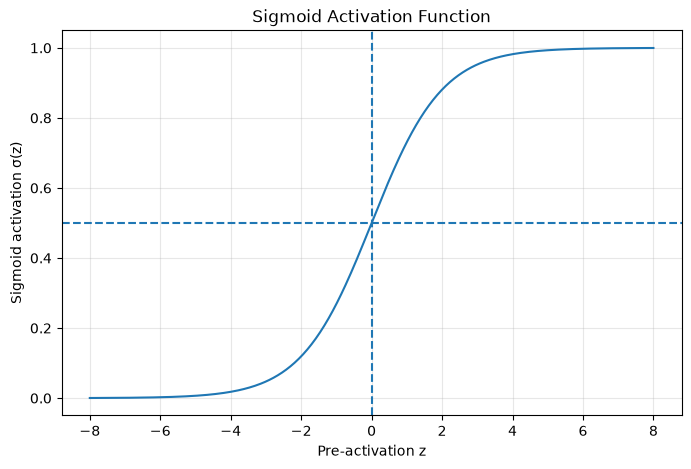

In [6]:
z_grid = np.linspace(-8, 8, 400) 
activation_grid = sigmoid(z_grid) 

plt.figure(figsize=(8, 5)) 
plt.plot(z_grid, activation_grid) 
plt.axhline(0.5, linestyle="--") 
plt.axvline(0.0, linestyle="--") 
plt.xlabel("Pre-activation z") 
plt.ylabel("Sigmoid activation σ(z)") 
plt.title("Sigmoid Activation Function") 
plt.grid(alpha=0.3) 
plt.show()

### Analysis
The sigmoid function is nonlinear.
Without a nonlinear activation function, multiple neural-network layers would collapse into a single linear transformation. The hidden layer would therefore not provide additional representational power.
The sigmoid transformation allows hidden neurons to learn nonlinear combinations of input pixels.

# Part III: Forward Propagation Through One Neuron
## 16. Mathematical Definition of a Single Neuron
Suppose one neuron receives (D) input features:
$$
x_1,x_2,\ldots,x_D.
$$
The neuron also has:
one weight (w_j) for each input feature;
one bias (b).
The weighted sum is
$$
w_1x_1+w_2x_2+\cdots+w_Dx_D+b.
$$
Using summation notation,
$$
\sum_{j=1}^{D}w_jx_j+b.
$$
The neuron output is
$$
a=\sigma(z).
$$
The forward calculation is therefore
$$
\sigma\left(
\sum_{j=1}^{D}w_jx_j+b
\right)
$$

## 17. Implement One Neuron With an Explicit Loop

In [7]:
def single_neuron_forward_loop(x, weights, bias):
    """
    Compute the forward pass of one sigmoid neuron using explicit loops.

    x : np.ndarray, shape (D,)
        Input feature vector.

    weights : np.ndarray, shape (D,)
        Weight associated with each input feature.

    bias : float
        Neuron bias.

    Returns
    z : float
        Pre-activation weighted sum.

    activation : float
        Sigmoid activation.
    """
    if x.ndim != 1:
        raise ValueError("x must be a one-dimensional array.")

    if weights.ndim != 1:
        raise ValueError("weights must be a one-dimensional array.")

    if len(x) != len(weights):
        raise ValueError(
            "x and weights must contain the same number of elements."
        )

    z = float(bias)

    for j in range(len(x)):
        z += float(weights[j]) * float(x[j])

    activation = float(sigmoid(z))

    return z, activation

## 18. Test the Single-Neuron Function
Consider the following small input:
$$
\begin{bmatrix}
0.5\
1.0\
-0.5
\end{bmatrix}.
$$
Let the weights be
$$
\begin{bmatrix}
0.2\
-0.4\
0.6
\end{bmatrix}
$$
and the bias be
$$
b=0.1.
$$

In [8]:
x_single = np.array([0.5, 1.0, -0.5])
weights_single = np.array([0.2, -0.4, 0.6])
bias_single = 0.1

z_single, activation_single = single_neuron_forward_loop(
    x=x_single,
    weights=weights_single,
    bias=bias_single
)

print("Pre-activation z:", z_single)
print("Activation a:", activation_single)


Pre-activation z: -0.5
Activation a: 0.3775406687981454


## 19. Manually Verify the Single Neuron
The weighted sum is
$$
(0.2)(0.5)
+
(-0.4)(1.0)
+
(0.6)(-0.5)
+
0.1.
$$
Calculate each weighted input separately:
$$
(0.2)(0.5)=0.1,
$$
$$
(-0.4)(1.0)=-0.4,
$$
$$
(0.6)(-0.5)=-0.3.
$$
Therefore,
$$
0.1-0.4-0.3+0.1=
-0.5.
$$
Apply the sigmoid function:
$$
\sigma(-0.5)=
\frac{1}{1+e^{0.5}}
\approx
0.3775407.
$$
The loop implementation therefore agrees with the manual calculation.


## 20. Inspect Every Contribution to the Neuron

In [9]:
running_total = bias_single

print(f"Initial value from bias: {running_total:.4f}")

for j in range(len(x_single)):
    contribution = weights_single[j] * x_single[j]
    running_total += contribution

    print(
        f"Feature {j}: "
        f"{weights_single[j]:.4f} × {x_single[j]:.4f} "
        f"= {contribution:.4f}; "
        f"running z = {running_total:.4f}"
    )

print(f"\nFinal z = {running_total:.4f}")
print(f"sigmoid(z) = {sigmoid(running_total):.6f}")


Initial value from bias: 0.1000
Feature 0: 0.2000 × 0.5000 = 0.1000; running z = 0.2000
Feature 1: -0.4000 × 1.0000 = -0.4000; running z = -0.2000
Feature 2: 0.6000 × -0.5000 = -0.3000; running z = -0.5000

Final z = -0.5000
sigmoid(z) = 0.377541


### Analysis
A neuron does not treat every feature equally.
Each weight controls how strongly an input contributes to the result:
- a positive weight increases (z) when the corresponding input is positive;
- a negative weight decreases (z) when the corresponding input is positive;
- a weight near zero causes the feature to have little influence;
- the bias shifts the weighted sum independently of the input.
  
During training, the neural network will adjust these weights and biases to improve its predictions.

# Part IV: Forward Propagation Through a Hidden Layer
## 21. Scalar Equation for Hidden Neuron (i)
Suppose the hidden layer contains (H) neurons.
For hidden neuron (i), the pre-activation is
$$
\sum_{j=1}^{D}
w_{ij}^{(1)}x_j
+
b_i^{(1)}.
$$
Its activation is
$$
\sigma\left(z_i^{(1)}\right).
$$
This process is repeated for every hidden neuron:
$$
i=1,2,\ldots,H.
$$
Each hidden neuron uses the same input vector $(\mathbf{x})$, but it has its own:
- weight vector;
- bias;
- pre-activation;
- activation.

## 22. Hidden-Layer Matrix Equation
The collection of scalar equations can be written compactly as
$$
\mathbf{z}^{(1)}=\
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}.
$$
Applying sigmoid element by element gives
$$
\sigma\left(\mathbf{z}^{(1)}\right).
$$

However, we will first implement these equations using nested loops rather than matrix multiplication.

## 23. Implement the Hidden Layer With Explicit Loops

In [10]:
def hidden_layer_forward_loop(x, W1, b1):
    """
    x : np.ndarray, shape (D,)
        Input vector.

    W1 : np.ndarray, shape (H, D)
        Hidden-layer weight matrix.

    b1 : np.ndarray, shape (H,)
        Hidden-layer bias vector.

    Returns
    z1 : np.ndarray, shape (H,)
        Hidden-layer pre-activations.

    a1 : np.ndarray, shape (H,)
        Hidden-layer sigmoid activations.
    """
    if x.ndim != 1:
        raise ValueError("x must be one-dimensional.")

    if W1.ndim != 2:
        raise ValueError("W1 must be two-dimensional.")

    if b1.ndim != 1:
        raise ValueError("b1 must be one-dimensional.")

    hidden_units, input_features = W1.shape

    if len(x) != input_features:
        raise ValueError(
            "The number of elements in x must match "
            "the number of columns in W1."
        )

    if len(b1) != hidden_units:
        raise ValueError(
            "The number of biases must match "
            "the number of rows in W1."
        )

    z1 = np.zeros(hidden_units, dtype=float)
    a1 = np.zeros(hidden_units, dtype=float)

    for i in range(hidden_units):
        z1[i] = float(b1[i])

        for j in range(input_features):
            z1[i] += float(W1[i, j]) * float(x[j])

        a1[i] = float(sigmoid(z1[i]))

    return z1, a1


### Explanation of the Outer Loop
The outer loop iterates across hidden neurons.
Each iteration computes one hidden neuron's output.
The row
$W1[i, :]$
contains all weights belonging to hidden neuron (i).

### Explanation of the Inner Loop
The inner loop iterates across input features.
For every input feature, the function calculates
$
w_{ij}^{(1)}x_j
$
and adds it to the current hidden neuron's weighted sum.
Thus, the nested loops correspond to
$$
\text{for every hidden neuron }i:
\quad
\text{sum across every input feature }j.
$$


# Part V: Output-Layer Forward Propagation
## 24. Scalar Equation for the Output Neuron
Once all hidden activations have been calculated, the output neuron receives
$$
a_1^{(1)},
a_2^{(1)},
\ldots,
a_H^{(1)}.
$$
The output pre-activation is
$$
\sum_{i=1}^{H}
w_i^{(2)}a_i^{(1)}
+
b^{(2)}.
$$
The final output is
$$
\sigma\left(z^{(2)}\right).
$$

## 25. Implement the Output Neuron With a Loop

In [11]:
def output_layer_forward_loop(a1, W2, b2):
    """
    a1 : np.ndarray, shape (H,)
        Hidden-layer activations.

    W2 : np.ndarray, shape (H,)
        Output-layer weights.

    b2 : float
        Output-layer bias.

    Returns
    z2 : float
        Output pre-activation.

    y_hat : float
        Predicted probability.
    """
    if a1.ndim != 1:
        raise ValueError("a1 must be one-dimensional.")

    if W2.ndim != 1:
        raise ValueError("W2 must be one-dimensional.")

    if len(a1) != len(W2):
        raise ValueError(
            "a1 and W2 must contain the same number of elements."
        )

    z2 = float(b2)

    for i in range(len(a1)):
        z2 += float(W2[i]) * float(a1[i])

    y_hat = float(sigmoid(z2))

    return z2, y_hat


## 26. Combine Both Layers Into a Complete Forward Pass

In [12]:
def forward_propagation_loop(x, W1, b1, W2, b2):
    """
    x : np.ndarray, shape (D,)
        Input vector.

    W1 : np.ndarray, shape (H, D)
        Input-to-hidden weights.

    b1 : np.ndarray, shape (H,)
        Hidden-layer biases.

    W2 : np.ndarray, shape (H,)
        Hidden-to-output weights.

    b2 : float
        Output bias.

    Returns
    cache : dict
        Intermediate values and final prediction.
    """
    z1, a1 = hidden_layer_forward_loop(x, W1, b1)
    z2, y_hat = output_layer_forward_loop(a1, W2, b2)

    cache = {
        "x": x,
        "z1": z1,
        "a1": a1,
        "z2": z2,
        "y_hat": y_hat
    }

    return cache

### Why Return a Cache?
The dictionary stores the intermediate values:
$$
\mathbf{x},
\quad
\mathbf{z}^{(1)},
\quad
\mathbf{a}^{(1)},
\quad
z^{(2)},
\quad
\hat{y}.
$$

These values will be required later during backpropagation.
Instead of recomputing them, we preserve them during the forward pass.

# Part VI: Manual Verification With a Tiny Synthetic Network
## 27. Why Use a Synthetic Example?
A full MNIST observation has 784 input values.
Manually checking 784 weighted multiplications for each hidden neuron would be impractical.
We therefore first construct a much smaller network:
$$
2 \longrightarrow 2 \longrightarrow 1.
$$
This network contains:
- two input features;
- two hidden neurons;
- one output neuron.
Because every number is small and explicitly defined, we can independently calculate the expected output by hand.
Only after confirming that the implementation is correct will we apply the same code to MNIST.

## 28. Define the Tiny Network
Let the input be
$$
\begin{bmatrix}
0.6\
0.2
\end{bmatrix}.
$$
Let the hidden-layer weight matrix be
$$
\begin{bmatrix}
0.5 & -0.4\\
0.3 & 0.8
\end{bmatrix}.
$$
The first row contains the weights of hidden neuron 1:
$$
\begin{bmatrix}
0.5 & -0.4
\end{bmatrix}.
$$
The second row contains the weights of hidden neuron 2:
$$
\begin{bmatrix}
0.3 & 0.8
\end{bmatrix}.
$$
Let the hidden biases be
$$
\begin{bmatrix}
0.1\
-0.2
\end{bmatrix}.
$$
Let the output weights be
$$
\begin{bmatrix}
0.7 & -0.5
\end{bmatrix}
$$
and the output bias be
$$
b^{(2)}=0.05.
$$

In [13]:
x_tiny = np.array([0.6, 0.2])

W1_tiny = np.array([
    [0.5, -0.4],
    [0.3,  0.8]
])

b1_tiny = np.array([0.1, -0.2])

W2_tiny = np.array([0.7, -0.5])

b2_tiny = 0.05

print("x shape:", x_tiny.shape)
print("W1 shape:", W1_tiny.shape)
print("b1 shape:", b1_tiny.shape)
print("W2 shape:", W2_tiny.shape)
print("b2 type:", type(b2_tiny))


x shape: (2,)
W1 shape: (2, 2)
b1 shape: (2,)
W2 shape: (2,)
b2 type: <class 'float'>


## 29. Manually Calculate Hidden Neuron 1
For hidden neuron 1,
$$
w_{11}^{(1)}x_1
+
w_{12}^{(1)}x_2
+
b_1^{(1)}.
$$
Substitute the values:
$$
(0.5)(0.6)
+
(-0.4)(0.2)
+
0.1.
$$
Calculate each term:
$$
(0.5)(0.6)=0.30,
$$
$$
(-0.4)(0.2)=-0.08.
$$
Therefore,
$$
0.30-0.08+0.10=
0.32.
$$
Apply sigmoid:
$$
\sigma(0.32)=
\frac{1}{1+e^{-0.32}}
\approx
0.579324.
$$


## 30. Manually Calculate Hidden Neuron 2
For hidden neuron 2,
$$
w_{21}^{(1)}x_1
+
w_{22}^{(1)}x_2
+
b_2^{(1)}.
$$
Substitute the values:
$$
(0.3)(0.6)+(0.8)(0.2)-0.20
$$
Calculate each term:
$$
(0.3)(0.6)=0.18,
$$
$$
(0.8)(0.2)=0.16.
$$
Therefore,
$$
0.18+0.16-0.20
=0.14.
$$
Apply sigmoid:
$$
\sigma(0.14)
\approx
0.534943.
$$
The hidden-layer vectors are therefore approximately
$$
\begin{bmatrix}
0.32\
0.14
\end{bmatrix}
$$
and
$$
\begin{bmatrix}
0.579324\
0.534943
\end{bmatrix}.
$$

## 31. Manually Calculate the Output Neuron
The output pre-activation is
$$
w_1^{(2)}a_1^{(1)}
+
w_2^{(2)}a_2^{(1)}
+
b^{(2)}.
$$
Substituting the values gives
$$
(0.7)(0.579324)
+
(-0.5)(0.534943)
+
0.05.
$$
Calculate the contributions:
$$
(0.7)(0.579324)
\approx
0.405527,
$$
$$
(-0.5)(0.534943)
\approx
-0.267471.
$$
Therefore,
$$
z^{(2)}
\approx
0.405527-0.267471+0.05
$$
$$
z^{(2)}
\approx
0.188056.
$$
The predicted probability is
$$
\sigma(0.188056)
\approx
0.546876.
$$
Therefore, the expected result of the tiny network is approximately
$$
\boxed{\hat{y}=0.546876}.
$$


## 32. Run the Loop Implementation

In [14]:
tiny_cache = forward_propagation_loop(
    x=x_tiny,
    W1=W1_tiny,
    b1=b1_tiny,
    W2=W2_tiny,
    b2=b2_tiny
)

print("Hidden pre-activations z1:")
print(tiny_cache["z1"])

print("\nHidden activations a1:")
print(tiny_cache["a1"])

print("\nOutput pre-activation z2:")
print(tiny_cache["z2"])

print("\nPredicted probability y_hat:")
print(tiny_cache["y_hat"])


Hidden pre-activations z1:
[0.32 0.14]

Hidden activations a1:
[0.57932425 0.53494295]

Output pre-activation z2:
0.18805550392501735

Predicted probability y_hat:
0.5468758109150145


### Analysis
The loop implementation matches the manually derived values:
$$
\mathbf{z}^{(1)}
\approx
\begin{bmatrix}
0.32\
0.14
\end{bmatrix},
$$
$$
\mathbf{a}^{(1)}
\approx
\begin{bmatrix}
0.579324\
0.534943
\end{bmatrix},
$$
$$
z^{(2)}
\approx
0.188056,
$$
$$
\hat{y}
\approx
0.546876.
$$
This agreement provides evidence that the scalar forward-propagation functions are correctly implementing the mathematical equations.

## 33. Print Every Operation in the Tiny Network
The following diagnostic function makes each multiplication visible.

In [15]:
def trace_forward_propagation(x, W1, b1, W2, b2):
    
    hidden_units, input_features = W1.shape
    hidden_activations = np.zeros(hidden_units)

    print("HIDDEN LAYER")
    print("-" * 50)

    for i in range(hidden_units):
        z = float(b1[i])

        print(f"\nHidden neuron {i}")
        print(f"Start with bias: {z:.6f}")

        for j in range(input_features):
            contribution = float(W1[i, j]) * float(x[j])
            z += contribution

            print(
                f"  Input {j}: "
                f"{W1[i, j]:.6f} × {x[j]:.6f} "
                f"= {contribution:.6f}; "
                f"running z = {z:.6f}"
            )

        activation = float(sigmoid(z))
        hidden_activations[i] = activation

        print(f"Final z1[{i}] = {z:.6f}")
        print(f"a1[{i}] = sigmoid({z:.6f}) = {activation:.6f}")

    print("\n\nOUTPUT LAYER")
    print("-" * 50)

    z2 = float(b2)
    print(f"Start with output bias: {z2:.6f}")

    for i in range(hidden_units):
        contribution = float(W2[i]) * hidden_activations[i]
        z2 += contribution

        print(
            f"  Hidden neuron {i}: "
            f"{W2[i]:.6f} × {hidden_activations[i]:.6f} "
            f"= {contribution:.6f}; "
            f"running z2 = {z2:.6f}"
        )

    y_hat = float(sigmoid(z2))

    print(f"\nFinal z2 = {z2:.6f}")
    print(f"y_hat = sigmoid({z2:.6f}) = {y_hat:.6f}")

    return y_hat
traced_prediction = trace_forward_propagation(
    x=x_tiny,
    W1=W1_tiny,
    b1=b1_tiny,
    W2=W2_tiny,
    b2=b2_tiny
)


HIDDEN LAYER
--------------------------------------------------

Hidden neuron 0
Start with bias: 0.100000
  Input 0: 0.500000 × 0.600000 = 0.300000; running z = 0.400000
  Input 1: -0.400000 × 0.200000 = -0.080000; running z = 0.320000
Final z1[0] = 0.320000
a1[0] = sigmoid(0.320000) = 0.579324

Hidden neuron 1
Start with bias: -0.200000
  Input 0: 0.300000 × 0.600000 = 0.180000; running z = -0.020000
  Input 1: 0.800000 × 0.200000 = 0.160000; running z = 0.140000
Final z1[1] = 0.140000
a1[1] = sigmoid(0.140000) = 0.534943


OUTPUT LAYER
--------------------------------------------------
Start with output bias: 0.050000
  Hidden neuron 0: 0.700000 × 0.579324 = 0.405527; running z2 = 0.455527
  Hidden neuron 1: -0.500000 × 0.534943 = -0.267471; running z2 = 0.188056

Final z2 = 0.188056
y_hat = sigmoid(0.188056) = 0.546876


## 34. Use Assertions to Verify the Manual Values

In [16]:
expected_z1 = np.array([0.32, 0.14])

expected_a1 = np.array([
    0.5793242521487495,
    0.5349429451582145
])

expected_z2 = 0.18805550392501735
expected_y_hat = 0.5468758109150145

assert np.allclose(tiny_cache["z1"], expected_z1)
assert np.allclose(tiny_cache["a1"], expected_a1)
assert np.isclose(tiny_cache["z2"], expected_z2)
assert np.isclose(tiny_cache["y_hat"], expected_y_hat)

print("All manual-verification tests passed.")

All manual-verification tests passed.


### Analysis
Assertions turn our manual calculations into reproducible tests.
If a future code change produces a different result, one of these assertions will fail. This will make it easier to detect mistakes before moving to larger datasets.

# Part VII: Verify the Loop Implementation With NumPy
## 35. Implement a Vectorized Forward Pass
Although the purpose of this notebook is scalar forward propagation, we can use matrix multiplication as an independent verification method.

In [17]:
# For one observation
def forward_propagation_vectorized(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = sigmoid(z1)

    z2 = W2 @ a1 + b2
    y_hat = sigmoid(z2)

    return {
        "x": x,
        "z1": z1,
        "a1": a1,
        "z2": float(z2),
        "y_hat": float(y_hat)
    }


The operator
@
performs matrix or vector multiplication.
The hidden-layer calculation
W1 @ x
simultaneously computes the weighted sums for all hidden neurons.


## 36. Compare Loop and Vectorized Results

In [18]:
tiny_vectorized_cache = forward_propagation_vectorized(
    x=x_tiny,
    W1=W1_tiny,
    b1=b1_tiny,
    W2=W2_tiny,
    b2=b2_tiny
)

print("Loop prediction:", tiny_cache["y_hat"])
print("Vectorized prediction:", tiny_vectorized_cache["y_hat"])
print(
    "Absolute difference:",
    abs(tiny_cache["y_hat"] - tiny_vectorized_cache["y_hat"])
)

Loop prediction: 0.5468758109150145
Vectorized prediction: 0.5468758109150145
Absolute difference: 0.0


In [19]:
# Verify every intermediate result:
assert np.allclose(
    tiny_cache["z1"],
    tiny_vectorized_cache["z1"]
)

assert np.allclose(
    tiny_cache["a1"],
    tiny_vectorized_cache["a1"]
)

assert np.isclose(
    tiny_cache["z2"],
    tiny_vectorized_cache["z2"]
)

assert np.isclose(
    tiny_cache["y_hat"],
    tiny_vectorized_cache["y_hat"]
)

print("Loop and vectorized implementations agree.")

Loop and vectorized implementations agree.


### Analysis
The two implementations perform the same mathematical operations.
The difference is how those operations are executed.
The loop implementation calculates each product individually in Python:
$$
w_{ij}x_j.
$$
The vectorized implementation delegates the calculation to optimized low-level numerical routines.
Therefore:
$$
\text{same mathematics}
\neq
\text{same computational efficiency}.
$$
This distinction will become one of the central experimental questions of the project.

# Part VIII: Initialize the MNIST Network
## 37. Parameter Initialization
We now return to the MNIST architecture:
$$
784 \longrightarrow 8 \longrightarrow 1.
$$
The network requires:
$$
\mathbf{W}^{(1)}
\in
\mathbb{R}^{8\times784},
$$
$$
\mathbf{b}^{(1)}
\in
\mathbb{R}^{8},
$$
$$
\mathbf{W}^{(2)}
\in
\mathbb{R}^{8},
$$
and
$$
b^{(2)}\in\mathbb{R}.
$$
We initialize the biases to zero.
For the weights, we use small random values rather than large random values. Large initial values could produce very large positive or negative pre-activations, pushing sigmoid outputs close to 0 or 1.

In [20]:
# For a one-hidden-layer neural network.
def initialize_parameters(input_size, hidden_size, rng):
    """
    input_size : int
        Number of input features.

    hidden_size : int
        Number of hidden neurons.

    rng : np.random.Generator
        NumPy random-number generator.

    Returns
    parameters : dict
        Dictionary containing W1, b1, W2, and b2.
    """
    W1 = rng.normal(
        loc=0.0,
        scale=np.sqrt(1.0 / input_size),
        size=(hidden_size, input_size)
    )

    b1 = np.zeros(hidden_size, dtype=float)

    W2 = rng.normal(
        loc=0.0,
        scale=np.sqrt(1.0 / hidden_size),
        size=hidden_size
    )

    b2 = 0.0

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }

    return parameters

In [21]:
# Initialize the network
mnist_parameters = initialize_parameters(
    input_size=input_size,
    hidden_size=hidden_size,
    rng=rng
)

W1_mnist = mnist_parameters["W1"]
b1_mnist = mnist_parameters["b1"]
W2_mnist = mnist_parameters["W2"]
b2_mnist = mnist_parameters["b2"]

## 38. Verify the Parameter Dimensions

In [22]:
print("W1 shape:", W1_mnist.shape)
print("b1 shape:", b1_mnist.shape)
print("W2 shape:", W2_mnist.shape)
print("b2:", b2_mnist)

W1 shape: (8, 784)
b1 shape: (8,)
W2 shape: (8,)
b2: 0.0


In [23]:
assert W1_mnist.shape == (hidden_size, input_size)
assert b1_mnist.shape == (hidden_size,)
assert W2_mnist.shape == (hidden_size,)
assert np.isscalar(b2_mnist)

print("All parameter dimensions are correct.")

All parameter dimensions are correct.


## 39. Inspect the Initial Parameter Distribution

In [24]:
print("W1 mean:", W1_mnist.mean())
print("W1 standard deviation:", W1_mnist.std())
print("W1 minimum:", W1_mnist.min())
print("W1 maximum:", W1_mnist.max())

print("\nW2 mean:", W2_mnist.mean())
print("W2 standard deviation:", W2_mnist.std())
print("W2 minimum:", W2_mnist.min())
print("W2 maximum:", W2_mnist.max())

W1 mean: -0.0003095178600599452
W1 standard deviation: 0.03584843357100885
W1 minimum: -0.1567540923166013
W1 maximum: 0.12335880008014934

W2 mean: 0.20352312595260694
W2 standard deviation: 0.5022666840705065
W2 minimum: -0.7621221207093978
W2 maximum: 1.0966822431471386


### Analysis
The weight values should be centered approximately around zero.

The initial parameters do not yet represent learned patterns such as:
- circular strokes associated with digit 0;
- central vertical strokes associated with digit 1;
- empty or filled regions in particular image locations.

Those patterns can only emerge after the network is trained.


# Part IX: Apply Scalar Forward Propagation to MNIST
## 40. Retrieve the Processed Data From Notebook 1
This section assumes that Notebook 1 produced the following arrays: 
X_train, y_train, X_test, y_test

The expected shapes are:
- X_train: (number of training observations, 784)
- y_train: (number of training observations,)
- X_test:  (number of test observations, 784)
- y_test:  (number of test observations,)
  
Each row of X_train should be a flattened, normalized image.

In [25]:
processed_data_directory = Path("data/processed")
output_path = processed_data_directory / "mnist_0_1_processed.npz"

with np.load(output_path) as saved_data:
    X_train = saved_data["X_train"]
    X_test = saved_data["X_test"]
    y_train = saved_data["y_train"].reshape(-1)
    y_test = saved_data["y_test"].reshape(-1)

In [26]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining feature minimum:", X_train.min())
print("Training feature maximum:", X_train.max())
print("Training labels:", np.unique(y_train))

X_train shape: (10133, 784)
y_train shape: (10133,)
X_test shape: (2115, 784)
y_test shape: (2115,)

Training feature minimum: 0.0
Training feature maximum: 1.0
Training labels: [0. 1.]


In [27]:
X_train.shape[1] == 784
X_train.min() >= 0
X_train.max() <= 1

assert X_train.ndim == 2
assert X_train.shape[1] == 784
assert y_train.ndim == 1
assert len(X_train) == len(y_train)

assert X_train.min() >= 0.0
assert X_train.max() <= 1.0

assert set(np.unique(y_train)).issubset({0, 1})

print("The processed MNIST data have the expected format.")

The processed MNIST data have the expected format.


## 41. Select One MNIST Observation

In [28]:
sample_index = 0

x_mnist_sample = X_train[sample_index]
y_mnist_sample = int(y_train[sample_index])

print("Input shape:", x_mnist_sample.shape)
print("True label:", y_mnist_sample)

Input shape: (784,)
True label: 1


## 42. Display the Selected Image

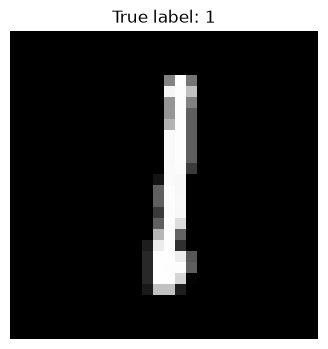

In [29]:
image_mnist_sample = x_mnist_sample.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(image_mnist_sample, cmap="gray")
plt.title(f"True label: {y_mnist_sample}")
plt.axis("off")
plt.show()

### Explanation
The neural network receives the flattened vector with shape
$
(784,),
$
but humans interpret the same information more naturally as a $(28\times28)$ image.
The reshape operation changes only the arrangement used for display. It does not alter the underlying pixel values.


## 43. Run Scalar Forward Propagation on the MNIST Image

In [30]:
mnist_loop_cache = forward_propagation_loop(
    x=x_mnist_sample,
    W1=W1_mnist,
    b1=b1_mnist,
    W2=W2_mnist,
    b2=b2_mnist
)

print("Hidden pre-activations:")
print(mnist_loop_cache["z1"])

print("\nHidden activations:")
print(mnist_loop_cache["a1"])

print("\nOutput pre-activation:")
print(mnist_loop_cache["z2"])

print("\nPredicted probability:")
print(mnist_loop_cache["y_hat"])

Hidden pre-activations:
[ 1.55978543e-01 -1.19029023e-01 -1.31097248e-04  3.86599108e-01
  3.19599743e-01 -3.31312292e-01 -6.07881811e-02 -2.42662384e-01]

Hidden activations:
[0.53891577 0.47027783 0.49996723 0.59546374 0.5792267  0.41792136
 0.48480763 0.43963035]

Output pre-activation:
0.7987185155112065

Predicted probability:
0.6897002924559879


## 44. Convert the Probability Into a Class Prediction

In [31]:
mnist_probability = mnist_loop_cache["y_hat"]

if mnist_probability >= 0.5:
    mnist_predicted_class = 1
else:
    mnist_predicted_class = 0

print("True label:", y_mnist_sample)
print("Predicted probability of digit 1:", mnist_probability)
print("Predicted class:", mnist_predicted_class)

True label: 1
Predicted probability of digit 1: 0.6897002924559879
Predicted class: 1


### Important Interpretation
The network has not been trained.
Its weights are random, so the predicted probability is also based on random parameter values.
Therefore, a correct prediction at this stage would not demonstrate that the network has learned the classification problem. It would be accidental.
Likewise, an incorrect prediction would not indicate a programming error.
The appropriate question at this stage is not
Is the prediction accurate?
The appropriate questions are:
- Are the dimensions correct?
- Does each neuron receive the intended inputs?
- Does the loop implement the mathematical equations?
- Does the loop result agree with the vectorized result?
- Is the final output between 0 and 1?

## 45. Verify the Output Range

In [32]:
assert 0.0 < mnist_loop_cache["y_hat"] < 1.0 
print("The output is a valid sigmoid probability.")

The output is a valid sigmoid probability.


## 46. Compare the MNIST Loop and Vectorized Calculations

In [33]:
mnist_vectorized_cache = forward_propagation_vectorized(
    x=x_mnist_sample,
    W1=W1_mnist,
    b1=b1_mnist,
    W2=W2_mnist,
    b2=b2_mnist
)

print("Loop prediction:", mnist_loop_cache["y_hat"])
print("Vectorized prediction:", mnist_vectorized_cache["y_hat"])

print(
    "Absolute difference:",
    abs(
        mnist_loop_cache["y_hat"]
        - mnist_vectorized_cache["y_hat"]
    )
)

# Verify all intermediate values:
assert np.allclose(
    mnist_loop_cache["z1"],
    mnist_vectorized_cache["z1"]
)

assert np.allclose(
    mnist_loop_cache["a1"],
    mnist_vectorized_cache["a1"]
)

assert np.isclose(
    mnist_loop_cache["z2"],
    mnist_vectorized_cache["z2"]
)

assert np.isclose(
    mnist_loop_cache["y_hat"],
    mnist_vectorized_cache["y_hat"]
)

print("The MNIST loop and vectorized calculations agree.")


Loop prediction: 0.6897002924559879
Vectorized prediction: 0.6897002924559879
Absolute difference: 0.0
The MNIST loop and vectorized calculations agree.


### Analysis
This is an important correctness check.
The scalar implementation explicitly calculates
$$
\sum_{j=1}^{784}
w_{ij}^{(1)}x_j
+
b_i^{(1)}
$$
for every hidden neuron.
The vectorized implementation calculates the same values using
$$
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}.
$$
Agreement between the two implementations demonstrates that vectorization changes how the operations are executed, but not the underlying mathematical model.

# Part X: Inspect an Individual MNIST Hidden Neuron
## 47. Examine One Hidden Neuron's Weighted Sum
To make the MNIST calculation more interpretable, we can inspect the contributions to one hidden neuron.

In [34]:
hidden_neuron_index = 0

manual_z = b1_mnist[hidden_neuron_index]

for pixel_index in range(input_size):
    manual_z += (
        W1_mnist[hidden_neuron_index, pixel_index]
        * x_mnist_sample[pixel_index]
    )

print("Manually accumulated z:", manual_z)
print(
    "Stored hidden-layer z:",
    mnist_loop_cache["z1"][hidden_neuron_index]
)
assert np.isclose(
    manual_z,
    mnist_loop_cache["z1"][hidden_neuron_index]
)

print("The individual hidden-neuron calculation is correct.")


Manually accumulated z: 0.15597854271977457
Stored hidden-layer z: 0.15597854271977457
The individual hidden-neuron calculation is correct.


## 48. Inspect the Largest Pixel Contributions
A contribution to the hidden neuron's weighted sum is
$$
w_{ij}^{(1)}x_j.
$$

In [35]:
pixel_contributions = (
    W1_mnist[hidden_neuron_index]
    * x_mnist_sample
)

largest_indices = np.argsort(
    np.abs(pixel_contributions)
)[-10:][::-1]

print("Ten largest absolute contributions:")
print()

for pixel_index in largest_indices:
    print(
        f"Pixel {pixel_index:>3}: "
        f"value={x_mnist_sample[pixel_index]:.4f}, "
        f"weight={W1_mnist[hidden_neuron_index, pixel_index]:.4f}, "
        f"contribution={pixel_contributions[pixel_index]:.6f}"
    )


Ten largest absolute contributions:

Pixel 629: value=0.9961, weight=-0.0862, contribution=-0.085833
Pixel 631: value=0.8353, weight=0.0910, contribution=0.076051
Pixel 463: value=0.9725, weight=-0.0740, contribution=-0.072003
Pixel 155: value=0.9922, weight=0.0631, contribution=0.062645
Pixel 630: value=0.9961, weight=0.0575, contribution=0.057308
Pixel 378: value=0.9804, weight=0.0573, contribution=0.056171
Pixel 462: value=0.9882, weight=-0.0568, contribution=-0.056102
Pixel 575: value=0.9333, weight=-0.0520, contribution=-0.048494
Pixel 211: value=0.9922, weight=-0.0474, contribution=-0.047000
Pixel 602: value=0.9922, weight=0.0455, contribution=0.045159


### Analysis
A pixel contributes strongly when both of the following are true:
the pixel value is relatively large;
the corresponding weight has a relatively large magnitude.
A black background pixel with normalized value near zero contributes very little, even when its weight is large:
$$
w_{ij}\times0\approx0.
$$
At initialization, the weights are random, so these large contributions do not yet have a learned interpretation.
After training, we can revisit this analysis to determine whether different hidden neurons respond to different image structures.

# Part XI: Forward Propagation for Multiple Observations
## 49. Loop Over Several MNIST Images
The current forward function processes one image at a time.
Let's apply it to several observations using an outer loop.

In [36]:
def predict_multiple_loop(X, W1, b1, W2, b2):
    """
    X : np.ndarray, shape (N, D)
        Collection of observations.

    Returns
    probabilities : np.ndarray, shape (N,)
        Predicted probability for each observation.
    """
    if X.ndim != 2:
        raise ValueError("X must be a two-dimensional array.")

    number_of_observations = X.shape[0]
    probabilities = np.zeros(number_of_observations)

    for observation_index in range(number_of_observations):
        cache = forward_propagation_loop(
            x=X[observation_index],
            W1=W1,
            b1=b1,
            W2=W2,
            b2=b2
        )

        probabilities[observation_index] = cache["y_hat"]

    return probabilities

In [37]:
# Apply it to the first five observations:
sample_probabilities = predict_multiple_loop(
    X=X_train[:5],
    W1=W1_mnist,
    b1=b1_mnist,
    W2=W2_mnist,
    b2=b2_mnist
)

sample_classes = (sample_probabilities >= 0.5).astype(int)

for observation_index in range(5):
    print(
        f"Observation {observation_index}: "
        f"true={int(y_train[observation_index])}, "
        f"probability={sample_probabilities[observation_index]:.6f}, "
        f"predicted={sample_classes[observation_index]}"
    )


Observation 0: true=1, probability=0.689700, predicted=1
Observation 1: true=1, probability=0.704358, predicted=1
Observation 2: true=1, probability=0.684682, predicted=1
Observation 3: true=0, probability=0.663783, predicted=1
Observation 4: true=1, probability=0.701667, predicted=1


### Analysis
This computation now contains three conceptual loop levels:
1. loop across observations;
2. loop across hidden neurons;
3. loop across input features.

For (N) observations, (H) hidden neurons, and (D) input features, the dominant hidden-layer computation requires approximately
$
NHD
$
multiplications.
For MNIST with $D=784$, this can become expensive when (N) and (H) increase.
This provides the motivation for vectorization and parallel numerical computation.


# Part XII: Computational Interpretation
## 50. Number of Operations for One Observation
For one input observation, the hidden layer performs approximately
$
HD
$
weight-input multiplications.

The output layer performs approximately
$
H
$
weight-activation multiplications.

The total number of multiplications is therefore approximately
$
HD+H.
$

For $D=784$ and $H=8$,
$$6272+8=6280$$



In [38]:
multiplications_per_observation = (
    hidden_size * input_size
    + hidden_size
)

print(
    "Approximate multiplications per observation:",
    multiplications_per_observation
)


Approximate multiplications per observation: 6280


For (N) observations, the approximate count becomes
$
N(HD+H).
$
 For 10,000 observations:

In [39]:
number_of_observations = 10_000

total_multiplications = (
    number_of_observations
    * multiplications_per_observation
)

print(
    "Approximate multiplications for 10,000 observations:",
    total_multiplications
)

Approximate multiplications for 10,000 observations: 62800000


### Analysis
The loop implementation is mathematically simple, but the number of individual operations grows rapidly.
Python must repeatedly:
- interpret each loop;
- retrieve each scalar value;
- multiply two Python or NumPy scalar objects;
- update the running sum.

Vectorized numerical libraries perform the same arithmetic in compiled low-level code and can make better use of processor instructions and memory access patterns.
Later notebooks will measure this difference empirically.


# Part XIII: Final Validation Tests
## 51. Check the Tiny Synthetic Network Again

In [40]:
def run_forward_propagation_tests():
    tiny_result = forward_propagation_loop(
        x=x_tiny,
        W1=W1_tiny,
        b1=b1_tiny,
        W2=W2_tiny,
        b2=b2_tiny
    )

    assert tiny_result["z1"].shape == (2,)
    assert tiny_result["a1"].shape == (2,)
    assert np.isscalar(tiny_result["z2"])
    assert np.isscalar(tiny_result["y_hat"])

    assert np.allclose(
        tiny_result["z1"],
        np.array([0.32, 0.14])
    )

    assert np.allclose(
        tiny_result["a1"],
        np.array([
            0.5793242521487495,
            0.5349429451582145
        ])
    )

    assert np.isclose(
        tiny_result["z2"],
        0.18805550392501735
    )

    assert np.isclose(
        tiny_result["y_hat"],
        0.5468758109150145
    )

    vectorized_result = forward_propagation_vectorized(
        x=x_tiny,
        W1=W1_tiny,
        b1=b1_tiny,
        W2=W2_tiny,
        b2=b2_tiny
    )

    assert np.allclose(
        tiny_result["z1"],
        vectorized_result["z1"]
    )

    assert np.allclose(
        tiny_result["a1"],
        vectorized_result["a1"]
    )

    assert np.isclose(
        tiny_result["z2"],
        vectorized_result["z2"]
    )

    assert np.isclose(
        tiny_result["y_hat"],
        vectorized_result["y_hat"]
    )

    print("All forward-propagation tests passed.")
run_forward_propagation_tests()

All forward-propagation tests passed.


# Part XIV: Notebook Conclusions
## 52. Main Findings
In this notebook, we specified a one-hidden-layer neural network for binary MNIST classification:
$$
784 \longrightarrow 8 \longrightarrow 1.
$$
For one observation, the hidden-layer forward equations are
$$
\sum_{j=1}^{784}
w_{ij}^{(1)}x_j
+
b_i^{(1)}
$$
and
$$
\sigma\left(z_i^{(1)}\right).
$$
The output-layer equations are
$$
\sum_{i=1}^{8}
w_i^{(2)}a_i^{(1)}
+
b^{(2)}
$$
and
$$
\sigma\left(z^{(2)}\right).
$$
We implemented these equations using explicit Python loops.
Before applying the implementation to MNIST, we verified it on a small synthetic network:
$$
2 \longrightarrow 2 \longrightarrow 1.
$$
The manual, loop-based, and vectorized calculations all produced
$$
\hat{y}
\approx
0.546876.
$$
This agreement demonstrates that the scalar implementation correctly represents the mathematical forward-propagation equations.

## 53. Research Interpretation
This notebook establishes an important distinction between a neural network's mathematical structure and its computational implementation.
Mathematically, the following expressions are equivalent:
$$
\sum_{j=1}^{D}
w_{ij}^{(1)}x_j+b_i^{(1)}
$$
and
$$
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}.
$$
Computationally, however, they may have substantially different execution times.
The explicit-loop version makes the model understandable because it exposes every individual multiplication and addition.
The vectorized version hides those scalar operations inside optimized matrix routines, but it can perform them far more efficiently.
Therefore, the scalar implementation provides the conceptual baseline for the project's later computational-efficiency comparisons.

# 54. Limitations of the Current Network
The network cannot yet learn because we have not defined:
- a loss function;
- derivatives of the loss;
- backpropagation;
- gradient descent;
- repeated training epochs.

The current weights are randomly initialized.
Consequently, the MNIST predictions generated in this notebook should not be interpreted as meaningful model performance.
The purpose of the current output is only to verify the forward computational graph:
$$
\mathbf{x}
\rightarrow
\mathbf{z}^{(1)}
\rightarrow
\mathbf{a}^{(1)}
\rightarrow
z^{(2)}
\rightarrow
\hat{y}.
$$


## 55. Preparation for the Next Notebook
The forward pass produces a probability
$
\hat{y}.
$
To train the network, we need a numerical measure of how different this prediction is from the true label (y).
For binary classification, we will introduce binary cross-entropy:
$$
\left[
y\log(\hat{y})
+
(1-y)\log(1-\hat{y})
\right].
$$
The next stage will connect this loss function to backpropagation.
We will derive how changes in each weight and bias affect the final loss, beginning at the output layer and moving backward through the network.


### Save important functions
These functions will be continuously used for future notebooks.

In [41]:
%%writefile neural_network_functions.py

import numpy as np


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def hidden_layer_forward_loop(x, W1, b1):
    """
    x : np.ndarray, shape (D,)
        One input observation.

    W1 : np.ndarray, shape (H, D)
        Input-to-hidden weights.

    b1 : np.ndarray, shape (H,)
        Hidden-layer biases.

    Returns
    z1 : np.ndarray, shape (H,)
        Hidden-layer pre-activations.

    a1 : np.ndarray, shape (H,)
        Hidden-layer activations.
    """
    hidden_units, input_features = W1.shape

    if x.shape != (input_features,):
        raise ValueError(
            f"x must have shape ({input_features},), "
            f"but received {x.shape}."
        )

    if b1.shape != (hidden_units,):
        raise ValueError(
            f"b1 must have shape ({hidden_units},), "
            f"but received {b1.shape}."
        )

    z1 = np.zeros(hidden_units, dtype=float)
    a1 = np.zeros(hidden_units, dtype=float)

    for i in range(hidden_units):
        z1[i] = float(b1[i])

        for j in range(input_features):
            z1[i] += float(W1[i, j]) * float(x[j])

        a1[i] = float(sigmoid(z1[i]))

    return z1, a1


def output_layer_forward_loop(a1, W2, b2):
    """
    a1 : np.ndarray, shape (H,)
        Hidden-layer activations.

    W2 : np.ndarray, shape (H,)
        Hidden-to-output weights.

    b2 : float
        Output-layer bias.

    Returns
    z2 : float
        Output pre-activation.

    y_hat : float
        Predicted probability.
    """
    if a1.shape != W2.shape:
        raise ValueError(
            f"a1 and W2 must have matching shapes, "
            f"but received {a1.shape} and {W2.shape}."
        )

    z2 = float(b2)

    for i in range(len(a1)):
        z2 += float(W2[i]) * float(a1[i])

    y_hat = float(sigmoid(z2))

    return z2, y_hat


def forward_propagation_loop(x, W1, b1, W2, b2):
    """
    Returns
    cache : dict
        Intermediate values required for backpropagation.
    """
    z1, a1 = hidden_layer_forward_loop(x, W1, b1)
    z2, y_hat = output_layer_forward_loop(a1, W2, b2)

    cache = {
        "x": x,
        "z1": z1,
        "a1": a1,
        "z2": z2,
        "y_hat": y_hat
    }

    return cache

Writing neural_network_functions.py
